# Exercise: Students

**Module 7: Categorical Outcomes** | Lean Six Sigma Data Analytics

---

## The Scenario

As a teacher, I am interested in what helps students to graduate.

One of the factors we have hypothesized about is the **knowledge of mathematics**.

We measured for 30 students their final grade at high school for math, and we want to know if this affects their chances to pass the first year in university.

**Question:** Is the probability of a successful first year related to the final math score in high school?

In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

# --- Minitab-style house style -------------------------------------------
import sys
from pathlib import Path as _Path

# minitab_style.py lives in the parent folder of each module directory
sys.path.append(str(_Path.cwd().parent))
import minitab_style as ms

ms.apply_style()

DATA_FILE = '../data/da-lss.xlsx'
xlsx = pd.ExcelFile(DATA_FILE)

print('Ready for student analysis!')


Ready for student analysis!


---

## Step 1: Identify Variables

First, determine what is my Y-variable and what is my X-variable:

| Variable | Description | Type |
|----------|-------------|------|
| Pass | Whether student passed first year (Yes/No) | Categorical — **Y/CTQ** |
| Math grade | Final grade in high school math | Numerical — **X/Influence factor** |

The Y-variable is **categorical** and the X-variable is **numerical**.

Our tree diagram shows us that we should perform a **logistic regression analysis**.

In [2]:
def load_students():
    """Load student data: Student, MathGrade, Pass"""
    df = pd.read_excel(xlsx, sheet_name='Student', skiprows=6, header=0, usecols=[0, 1, 2])
    df.columns = ['Student', 'MathGrade', 'Pass']
    # Remove rows with missing math grades (marked as '*')
    df = df[df['MathGrade'] != '*']
    df['MathGrade'] = df['MathGrade'].astype(int)
    # Convert Pass to binary (1 = Yes, 0 = No)
    df['PassBinary'] = (df['Pass'] == 'Yes').astype(int)
    return df

students = load_students()
print('ORIGINAL DATA')
print('=' * 50)
print(students.to_string(index=False))
print(f'\nTotal students (with valid math grade): {len(students)}')

ORIGINAL DATA
 Student  MathGrade Pass  PassBinary
       1          7   No           0
       2          7  Yes           1
       4          8   No           0
       5          8  Yes           1
       6          9   No           0
       7          9   No           0
       8          5   No           0
       9          7   No           0
      10          9  Yes           1
      11          8   No           0
      12         10  Yes           1
      13         10  Yes           1
      15          6   No           0
      16          9  Yes           1
      17          9  Yes           1
      18          6   No           0
      20          8  Yes           1
      21          8   No           0
      22          7   No           0
      23          7   No           0
      25          6   No           0
      26          6   No           0
      27         10  Yes           1
      29          8  Yes           1
      30          9  Yes           1

Total students (with va

---

## Step 2: Transform Data to Event/Trial Format

Remember the three steps of logistic regression:
1. Put data in event/trial format
2. Make a fitted line plot and evaluate the fit
3. Check if results are statistically significant

The **event/trial format** requires:
- A column with X-variable values (all possible grades)
- A column with number of **events** (students who passed)
- A column with number of **trials** (total students with that grade)

We use cross-tabulation to transform the data.

In [3]:
# Create cross-tabulation
crosstab = pd.crosstab(students['MathGrade'], students['Pass'])

print('CROSS-TABULATION')
print('=' * 50)
print(crosstab)
print()
print('For example, for grade 7:')
print(f'  {crosstab.loc[7, "No"]} students did NOT pass')
print(f'  {crosstab.loc[7, "Yes"]} student DID pass')
print(f'  Total: {crosstab.loc[7].sum()} students with grade 7')

CROSS-TABULATION
Pass       No  Yes
MathGrade         
5           1    0
6           4    0
7           4    1
8           3    3
9           2    4
10          0    3

For example, for grade 7:
  4 students did NOT pass
  1 student DID pass
  Total: 5 students with grade 7


In [4]:
# Convert to event/trial format
event_trial = pd.DataFrame({
    'MathGrade': crosstab.index,
    'Pass': crosstab['Yes'].values,  # Events (passed)
    'Students': crosstab.sum(axis=1).values  # Total trials
})

print('EVENT/TRIAL FORMAT')
print('=' * 50)
print(event_trial.to_string(index=False))
print()
print('MathGrade = X variable (predictor)')
print('Pass = Number of events (students who passed)')
print('Students = Number of trials (total students with that grade)')

EVENT/TRIAL FORMAT
 MathGrade  Pass  Students
         5     0         1
         6     0         4
         7     1         5
         8     3         6
         9     4         6
        10     3         3

MathGrade = X variable (predictor)
Pass = Number of events (students who passed)
Students = Number of trials (total students with that grade)


---

## Step 3: Fitted Line Plot

Now we make a fitted line plot and evaluate the fit.

In [5]:
# Calculate observed proportions
event_trial['Proportion'] = event_trial['Pass'] / event_trial['Students']

# Fit logistic regression model
X = sm.add_constant(event_trial['MathGrade'])
model = sm.GLM(event_trial['Proportion'], X,
               family=sm.families.Binomial(),
               freq_weights=event_trial['Students'])
results = model.fit()

print('LOGISTIC REGRESSION MODEL FITTED')
print('=' * 50)

LOGISTIC REGRESSION MODEL FITTED

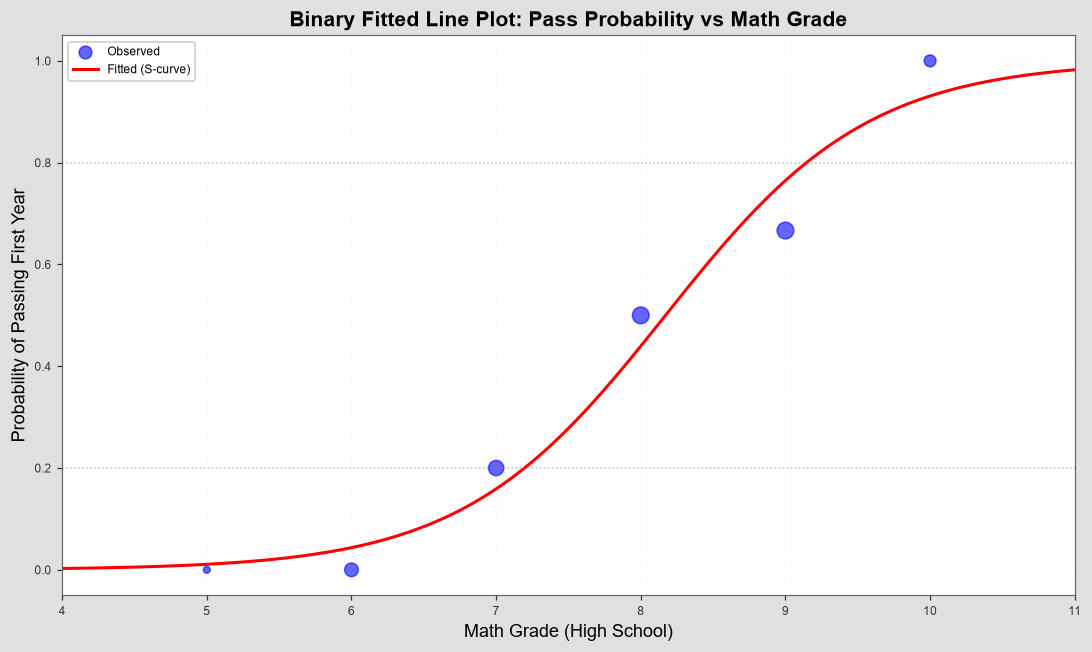

In [6]:
# Create fitted line plot (Binary Fitted Line Plot)
fig, ax = plt.subplots(figsize=(10, 6))

# Get model coefficients
intercept = results.params['const']
coef = results.params['MathGrade']

# Plot observed proportions (size proportional to number of students)
ax.scatter(event_trial['MathGrade'], event_trial['Proportion'], 
           s=event_trial['Students']*20, alpha=0.6, color='blue', label='Observed')

# Generate smooth prediction curve (S-curve)
x_range = np.linspace(4, 11, 100)
y_pred = 1 / (1 + np.exp(-(intercept + coef * x_range)))

ax.plot(x_range, y_pred, color='red', linewidth=2, label='Fitted (S-curve)')

ax.set_xlabel('Math Grade (High School)', fontsize=12)
ax.set_ylabel('Probability of Passing First Year', fontsize=12)
ax.set_title('Binary Fitted Line Plot: Pass Probability vs Math Grade', fontsize=14)
ax.set_ylim(-0.05, 1.05)
ax.set_xlim(4, 11)
ax.legend()
ax.grid(True, alpha=0.3)

# Add reference lines
ax.axhline(y=0.2, color='gray', linestyle=':', alpha=0.5)
ax.axhline(y=0.8, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

In [7]:
print('INTERPRETATION OF FITTED LINE PLOT')
print('=' * 50)
print()
print('The fitted line plot shows a slightly bending UPWARD line.')
print()
print('This indicates that the chance of passing the first year')
print('INCREASES as the math grade in high school IMPROVES.')
print()

# Predictions at specific grades
for grade in [7, 9]:
    prob = 1 / (1 + np.exp(-(intercept + coef * grade)))
    print(f'Students with grade {grade}:')
    print(f'  Probability of passing ≈ {prob:.0%}')
    print()

INTERPRETATION OF FITTED LINE PLOT

The fitted line plot shows a slightly bending UPWARD line.

This indicates that the chance of passing the first year
INCREASES as the math grade in high school IMPROVES.

Students with grade 7:
  Probability of passing ≈ 16%

Students with grade 9:
  Probability of passing ≈ 76%



---

## Step 4: Check Significance (P-Value)

We still have to decide whether these results are statistically significant.

**Hypotheses:**
- **H₀ (Null):** Math grade and passing probability are NOT related
- **H₁ (Alternative):** Math grade and passing probability ARE related

In [8]:
print('LOGISTIC REGRESSION SUMMARY')
print('=' * 50)
print(results.summary())

LOGISTIC REGRESSION SUMMARY
                 Generalized Linear Model Regression Results                  
Dep. Variable:             Proportion   No. Observations:                    6
Model:                            GLM   Df Residuals:                       23
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -7.5810
Date:                Thu, 08 Oct 2026   Deviance:                       1.2515
Time:                        12:20:30   Pearson chi2:                    0.890
No. Iterations:                     5   Pseudo R-squ. (CS):             0.8666
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -11.6267   

In [9]:
# Extract key statistics
pvalue = results.pvalues['MathGrade']

print('KEY RESULTS')
print('=' * 50)
print(f'\nIntercept (β₀): {intercept:.4f}')
print(f'MathGrade coefficient (β₁): {coef:.4f}')
print(f'\nP-value for MathGrade: {pvalue:.6f}')
print()

if pvalue < 0.05:
    print('The p-value is very small (< 0.05).')
    print()
    print('This means we found a STATISTICALLY SIGNIFICANT relationship.')
    print('The alternative hypothesis can be supported.')
else:
    print('The p-value is larger than 0.05.')
    print('The relationship is NOT statistically significant.')

KEY RESULTS

Intercept (β₀): -11.6267
MathGrade coefficient (β₁): 1.4230

P-value for MathGrade: 0.010551

The p-value is very small (< 0.05).

This means we found a STATISTICALLY SIGNIFICANT relationship.
The alternative hypothesis can be supported.


---

## Caution: Causality

**Important note:** You should always be careful with causality!

Math grade is a **predictor** of passing probability. But this does NOT mean that if we offered additional math tutoring to students in the first year, they would immediately have a higher probability of passing.

It could be that there is a **third variable** (like intellect or discipline) that influences BOTH:
- Math grade in high school
- Probability of passing the first year

Correlation does not imply causation!

---

## Summary

In [10]:
print('FINAL ANSWER')
print('=' * 50)
print()
print('We transformed the data into event/trial format using cross-tabulation.')
print()
print('The fitted line plot showed a POSITIVE relationship between')
print('math grade in high school and chances of passing first year.')
print()
print(f'The p-value ({pvalue:.4f}) shows the results are SIGNIFICANT')
print('and NOT due to random fluctuations.')
print()
print('Conclusion: Yes, the probability of a successful first year')
print('IS related to the final math score in high school.')

FINAL ANSWER

We transformed the data into event/trial format using cross-tabulation.

The fitted line plot showed a POSITIVE relationship between
math grade in high school and chances of passing first year.

The p-value (0.0106) shows the results are SIGNIFICANT
and NOT due to random fluctuations.

Conclusion: Yes, the probability of a successful first year
IS related to the final math score in high school.


---

## Key Takeaways

| Step | Action | Result |
|------|--------|--------|
| 1 | Identify variables | Y: Pass (categorical), X: Math grade (numerical) → Logistic regression |
| 2 | Transform to event/trial format | Use cross-tabulation to group by math grade |
| 3 | Fitted line plot | Upward curve: higher grades → higher pass probability |
| 4 | Check p-value | Significant relationship (p < 0.05) |

**Key Insight:** Be careful about inferring causality. A predictor relationship does not mean that changing the predictor will change the outcome — there may be confounding variables.